In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.feature_selection import SelectKBest,f_classif
from lightgbm import LGBMClassifier
import shap
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif']=['SimHei']

d:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("F:/album/NephrotoxicDrug/CKD_NephrotoxicDrug_Dataset.csv")

In [3]:
print("形状：", df.shape)
print("数据示例：\n",df.head())
print("列名：\n", df.columns.tolist())
print("\n数据类型：\n", df.dtypes)
print("描述性统计：\n", df.describe())

形状： (1500, 37)
数据示例：
    patient_age  gender  bp_systolic  bp_diastolic  blood_urea  \
0           69    Male        136.5          90.4        45.3   
1           32    Male        125.0          62.6        22.4   
2           89  Female        124.2          71.1        36.0   
3           78    Male         98.7          81.6         4.7   
4           38    Male        147.7          81.4        56.6   

   serum_creatinine  albumin  blood_glucose_random  diabetes  hypertension  \
0              1.42        2                 175.2         0             1   
1              0.66        0                 138.0         0             0   
2              1.72        0                 177.2         0             0   
3              0.34        0                 121.6         0             0   
4              1.39        0                  65.4         0             1   

   ... bioavailability_pct  volume_of_distribution  kidney_cell_viability_pct  \
0  ...               53.69           

In [4]:
print("缺失值：\n",df.isnull().sum())

缺失值：
 patient_age                    0
gender                         0
bp_systolic                    0
bp_diastolic                   0
blood_urea                     0
serum_creatinine               0
albumin                        0
blood_glucose_random           0
diabetes                       0
hypertension                   0
drug_name                      0
drug_dosage_mg                 0
exposure_days                  0
nephrotoxic_label              0
mol_weight                     0
logP                           0
hbond_donors                   0
hbond_acceptors                0
rotatable_bonds                0
tpsa                           0
shape_index_3d                 0
inertia_x                      0
inertia_y                      0
inertia_z                      0
charge_distribution            0
clearance_rate                 0
half_life_hr                   0
bioavailability_pct            0
volume_of_distribution         0
kidney_cell_viability_pct      0
mito

In [5]:
target = 'ckd_risk_label'
X = df.drop(columns=target)
y = df[target]

In [6]:
# 检查目标变量y的分布
print(y.value_counts())

ckd_risk_label
1    728
2    393
0    379
Name: count, dtype: int64


In [7]:
# 预处理
# 1.把性别、药物名称、转化为category
category_features = ['gender','drug_name']
for col in category_features:
    X[col] = X[col].astype('category')

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=67,stratify=y
    )

print("train_volume:",len(X_train),"test_volume:",len(X_test),)

train_volume: 1200 test_volume: 300


In [9]:
# base_line 逻辑回归
# 做逻辑回归前先将数据标准化
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

X_train_lr = pd.get_dummies(X_train_lr,columns=category_features,drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr,columns=category_features,drop_first=True)

X_test_lr = X_test_lr.reindex(columns=X_train_lr.columns,fill_value=0)
#防止列顺序不一致

In [10]:
X_train_scaled = StandardScaler().fit_transform(X_train_lr)
X_test_scaled = StandardScaler().fit_transform(X_test_lr)

lr = LogisticRegression(solver="lbfgs",max_iter= 1000,random_state=67)
lr.fit(X_train_scaled,y_train)
y_pred_lr = lr.predict(X_test_scaled)



逻辑回归(base line)
准确率: 0.7833
分类报告:
               precision    recall  f1-score   support

           0     0.8571    0.7895    0.8219        76
           1     0.7547    0.8219    0.7869       146
           2     0.7746    0.7051    0.7383        78

    accuracy                         0.7833       300
   macro avg     0.7955    0.7722    0.7824       300
weighted avg     0.7858    0.7833    0.7831       300



<function matplotlib.pyplot.show(close=None, block=None)>

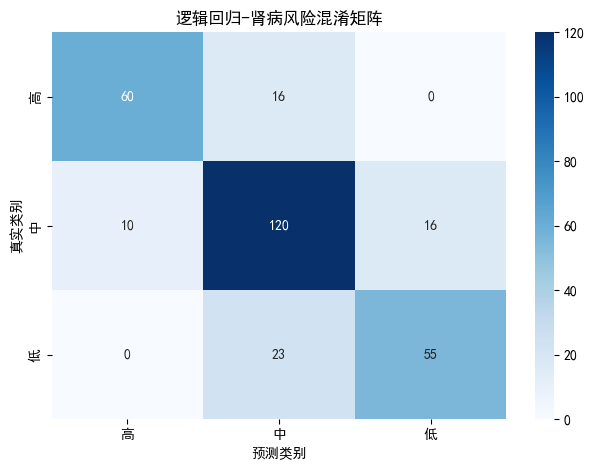

In [11]:
print("\n逻辑回归(base line)")
print("准确率: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("分类报告:\n", classification_report(y_test, y_pred_lr, digits=4))

cm = confusion_matrix(y_test, y_pred_lr)
plt.Figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['高','中','低'],
            yticklabels=['高','中','低'])
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('逻辑回归-肾病风险混淆矩阵')
plt.tight_layout()
plt.show

In [12]:
# 使用LightGBM进行分类预测
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class = 3,
    boosting_type='gbdt',
    num_leaves= 32,
    learning_rate= 0.5,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq = 5,
    n_estimators=1000,
    early_stopping_rounds = 50,
    random_state= 67,
    verbose= -1
)

In [13]:
lgb_model.fit(X_train,
              y_train,
              eval_set=[(X_test,y_test)],
              eval_metric='multi_logloss',
              categorical_feature=category_features)
y_pred_lgb = lgb_model.predict(X_test)
#y_pred_lgb_proba = lgb_model.predict_proba(X_test)
print("准确率:", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))

准确率: 0.9466666666666667
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        76
           1       0.94      0.95      0.95       146
           2       0.97      0.95      0.96        78

    accuracy                           0.95       300
   macro avg       0.95      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300



<function matplotlib.pyplot.show(close=None, block=None)>

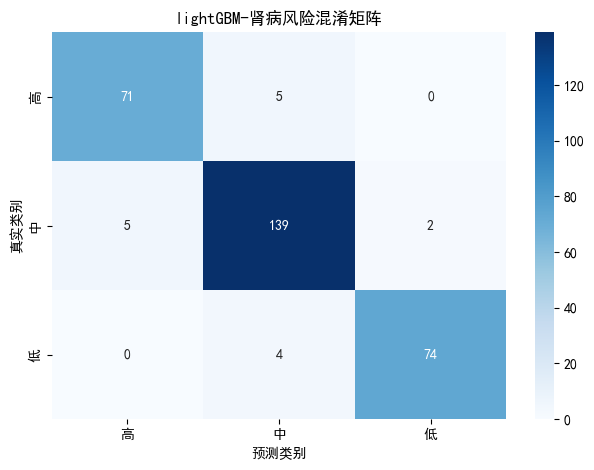

In [14]:
cm = confusion_matrix(y_test, y_pred_lgb)
plt.Figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['高','中','低'],
            yticklabels=['高','中','低'])
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('lightGBM-肾病风险混淆矩阵')
plt.tight_layout()
plt.show

                             特征         重要性
5              serum_creatinine  404.661264
13            nephrotoxic_label  386.514605
4                    blood_urea  383.773198
10                    drug_name  220.184140
34     toxicity_score_composite  191.390013
8                      diabetes  185.536255
9                  hypertension  140.819656
33  serum_creatinine_change_pct  131.322493
29    kidney_cell_viability_pct  120.837193
30         mitochondrial_damage   35.058661
22                    inertia_y   31.729293
15                         logP   26.060133
24          charge_distribution   25.179683
11               drug_dosage_mg   24.976934
23                    inertia_z   24.967370
0                   patient_age   24.294824
7          blood_glucose_random   24.137030
21                    inertia_x   23.845166
20               shape_index_3d   23.604584
19                         tpsa   23.545117


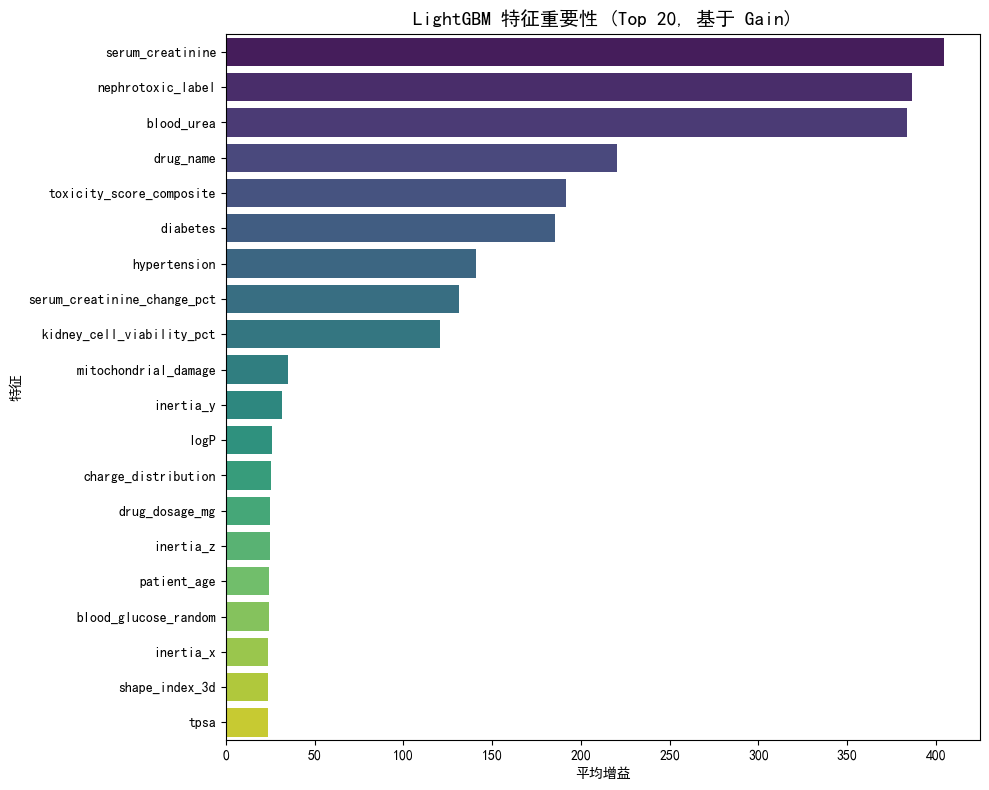

In [18]:
importance_gain = lgb_model.booster_.feature_importance(importance_type='gain')
feature_names = X_train.columns
imp_df = pd.DataFrame({
    '特征':feature_names,
    '重要性':importance_gain
}).sort_values('重要性',ascending = False)
print(imp_df.head(20))
plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(20), x='重要性', y='特征', palette='viridis')
plt.title('LightGBM 特征重要性 (Top 20, 基于 Gain)', fontsize=14)
plt.xlabel('平均增益')
plt.tight_layout()
plt.show()